# 3. Edge Orchestrator and Grid-Limit Sensitivity

Demonstrates the deterministic load-shaping rule on top of the trained forecasters: a single decision, the aggregate throttle rate over the full test horizon, a sweep of the safe grid-limit parameter, and the supporting temporal-error and charger-utilization breakdowns.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from evloadshaping.analysis import charger_utilization_stats, hourly_error_breakdown
from evloadshaping.data import load_extended_raw, load_raw_data
from evloadshaping.features import build_features, split_data
from evloadshaping.models import train_model
from evloadshaping.orchestrator import (
    edge_orchestrator,
    grid_limit_sensitivity,
    summarize_orchestration,
)
from evloadshaping.plotting import plot_grid_sensitivity

DATA_PATH = Path('../data/20260514_uma_adabyron_data.csv')
GRID_LIMIT = 5000.0

## Rebuild the forecasters

Self-contained: reloads the data and retrains both models so this notebook runs independently of the others (a few seconds each).

In [2]:
raw_frame, charger_ids = load_raw_data(DATA_PATH)
feature_frame = build_features(raw_frame, charger_ids)
x_train, x_test, y_pv_train, y_pv_test, y_ev_train, y_ev_test = split_data(feature_frame)

model_pv = train_model(x_train, y_pv_train)
model_ev = train_model(x_train, y_ev_train)

pv_predictions = model_pv.predict(x_test)
ev_predictions = model_ev.predict(x_test)

## A single edge decision

The orchestrator compares the forecast for one interval against the safe grid limit and issues a stable / throttle / inspect decision.

In [3]:
test_state = x_test.iloc[0]
decision = edge_orchestrator(
    predicted_pv=float(pv_predictions[0]),
    predicted_ev=float(ev_predictions[0]),
    current_evs_connected=int(round(float(test_state['total_evs_connected']))),
    grid_limit=GRID_LIMIT,
)
decision

{'status': 'inspect',
 'message': 'High demand forecasted but no EVs are connected. Check sensor integrity.',
 'predicted_pv': 47.25394058227539,
 'predicted_ev': 32.806922912597656,
 'current_evs_connected': 0,
 'grid_limit': 5000.0}

## Aggregate throttle rate over the full test horizon

Running the same rule on every test interval, rather than just the first one, gives a much more representative picture.

In [4]:
orchestration_stats = summarize_orchestration(
    pv_predictions,
    ev_predictions,
    x_test['total_evs_connected'].to_numpy(),
    grid_limit=GRID_LIMIT,
)
orchestration_stats

{'n_intervals': 11537,
 'n_stable': 11526,
 'n_throttle': 11,
 'n_inspect': 0,
 'throttle_rate': 0.0009534541041865303,
 'mean_reduction_per_ev_w': 786.8160600142045,
 'max_reduction_per_ev_w': 1797.58837890625}

## Grid-limit sensitivity sweep

How does the throttle rate and the mean per-EV reduction change as the safe grid import limit is relaxed from 1 kW to 12 kW?

In [5]:
sensitivity = grid_limit_sensitivity(
    pv_predictions,
    ev_predictions,
    x_test['total_evs_connected'].to_numpy(),
    grid_limits=[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 10000, 12000],
)
sensitivity

,grid_limit_w,n_intervals,n_stable,n_throttle,n_inspect,throttle_rate,mean_reduction_per_ev_w,max_reduction_per_ev_w
0,1000,11537,11468,69,0,0.005981,954.582699,5797.588379
1,2000,11537,11502,35,0,0.003034,1130.462916,4797.588379
2,3000,11537,11518,19,0,0.001647,1273.658198,3797.588379
3,4000,11537,11524,13,0,0.001127,1138.644908,2797.588379
4,5000,11537,11526,11,0,0.000953,786.816060,1797.588379
5,6000,11537,11527,10,0,0.000867,314.320160,797.588379
6,7000,11537,11533,4,0,0.000347,68.027323,123.284668
7,8000,11537,11537,0,0,0.000000,0.000000,0.000000
8,10000,11537,11537,0,0,0.000000,0.000000,0.000000
9,12000,11537,11537,0,0,0.000000,0.000000,0.000000


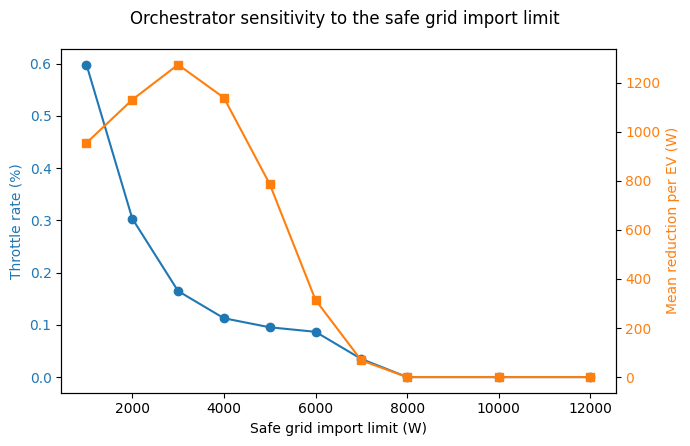

In [6]:
fig = plot_grid_sensitivity(sensitivity)
plt.show()

## Forecast error by time of day

Buckets the absolute forecast error into 3-hour windows — both targets are hardest to forecast around midday, when PV output is most variable.

In [7]:
hourly_errors = hourly_error_breakdown(
    x_test.index, y_pv_test, pv_predictions, y_ev_test, ev_predictions
)
hourly_errors

,hour_bucket,pv_mae,ev_mae,n,hour_range
0,0,21.079947,2.285591,1440,00-03
1,3,40.273507,6.560696,1440,03-06
2,6,408.709242,173.985503,1450,06-09
3,9,1186.494385,171.490896,1447,09-12
4,12,1299.306916,92.941261,1440,12-15
5,15,565.949064,54.106505,1440,15-18
6,18,59.587684,12.555399,1440,18-21
7,21,46.279035,3.638534,1440,21-00


## Per-charger utilization

Cumulative energy delivered and the active-charging share for each charger over the full telemetry span, independent of the 15-minute forecasting split.

In [8]:
extended_frame = load_extended_raw(DATA_PATH, charger_ids)
charger_stats = charger_utilization_stats(extended_frame, charger_ids)
charger_stats

,charger_id,total_energy_delivered_kwh,pct_time_charging
0,1,3708.303,4.744554
1,2,4439.249,5.426296
2,3,5781.947,6.282057
3,4,6733.948,7.266503
4,5,8124.436,8.440123


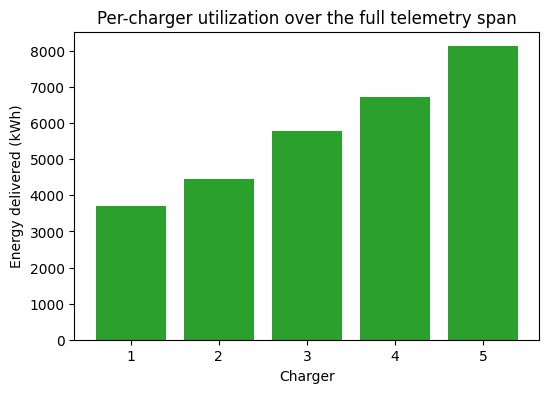

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(charger_stats['charger_id'].astype(str), charger_stats['total_energy_delivered_kwh'], color='tab:green')
ax.set_xlabel('Charger')
ax.set_ylabel('Energy delivered (kWh)')
ax.set_title('Per-charger utilization over the full telemetry span')
plt.show()